# 🗺️ Mission 6: Map the City

```{admonition} Your mission
:class: tip

The charts revealed patterns — but **where do they occur?**

In this mission, you will:

- 🗺️ explore the spatial structure of the Berlin data
- 🌳 map canopy indicators
- 🎨 create a clear thematic map
- 🔎 interpret spatial patterns across the city

🏅 **Badge to unlock:** Spatial Explorer

# 📍 From data to location

>Our GeoPackage contains something that an ordinary table does not: **geometry**.

Each observation represents a 100 m grid cell with a location and shape. This allows us to put our indicators on a map.

In [6]:
import geopandas as gpd

berlin = gpd.read_file(
    "data/g_raw/berlin_3D_canopy_stats_lczv3_grid100m_urau2021_epsg25833.gpkg"
)
berlin.geometry.head()

/opt/conda/envs/worker_env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


0    MULTIPOLYGON (((397000 5822000, 396900 5822000...
1    MULTIPOLYGON (((397000 5822100, 396900 5822100...
2    MULTIPOLYGON (((397000 5822200, 396900 5822200...
3    MULTIPOLYGON (((397000 5822300, 396900 5822300...
4    MULTIPOLYGON (((397100 5822000, 397093 5822000...
Name: geometry, dtype: geometry

>The `geometry` column stores the shape of each grid cell.

Let's first draw these geometries without using any indicator.

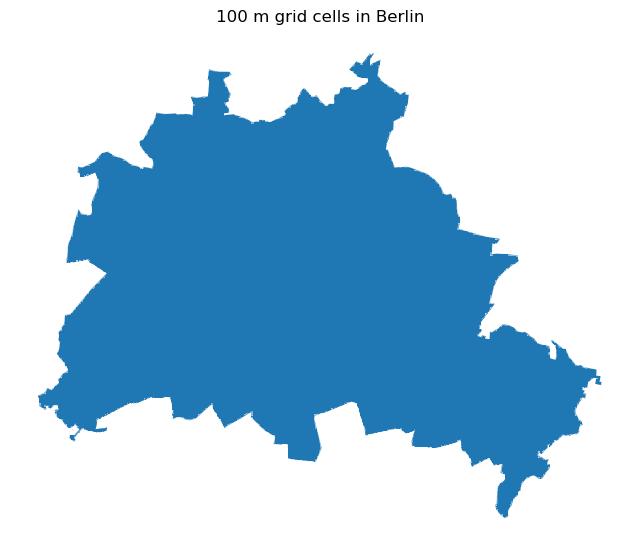

In [8]:
import matplotlib.pyplot as plt

berlin.plot(
    figsize=(8, 8),
    edgecolor="none"
)

plt.title("100 m grid cells in Berlin")
plt.axis("off")
plt.show()

In [20]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output1_png = download_dir / "100m_grid_cell_Berlin.png"
#output1_pdf = download_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

fig.savefig(output1_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/100m_grid_cell_Berlin.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

```{admonition}
:class: tip

This dataset contains many 100 m grid cells. Drawing all of them can take a little time, so don't worry if the map does not appear immediately.
```

We can see **where the observations are**, but the map does not yet tell us anything about urban forest structure.

Let's add our canopy evidence.

# 🌳 Map canopy volume

In the previous missions, we explored `chm_volume ', aka canopy volume, using statistics and charts.

Now we can see **where high and low canopy-volume values occur**.

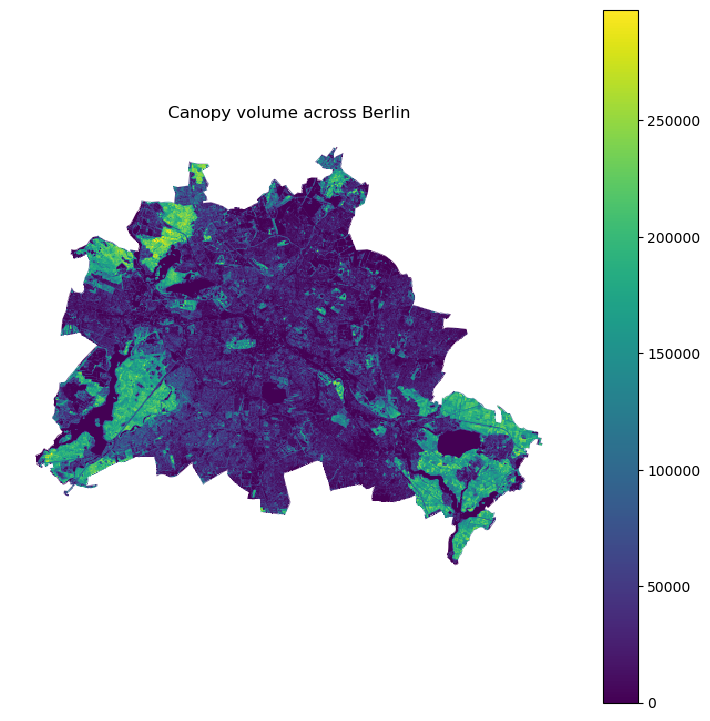

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))

berlin.plot(
    column="chm_volume",
    legend=True,
    ax=ax
)

ax.set_title("Canopy volume across Berlin")
ax.set_axis_off()

plt.show()

In [21]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output2_png = download_dir / "canopy_volume_across_Berlin.png"
#output1_pdf = download_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

fig.savefig(output2_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/canopy_volume_across_Berlin.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

```{admonition} 🔍 Evidence check
:class: note

Look across the map rather than focusing on individual cells.

- Is canopy volume evenly distributed?
- Can you see clusters of higher or lower values?
- Which parts of the study area catch your attention?

You have moved from asking **“How much?”** to asking **“Where?”**

# 🎨 Refine the map

The first thematic map works, but we can make the message clearer.

A good map should guide the reader toward the data without unnecessary visual clutter.

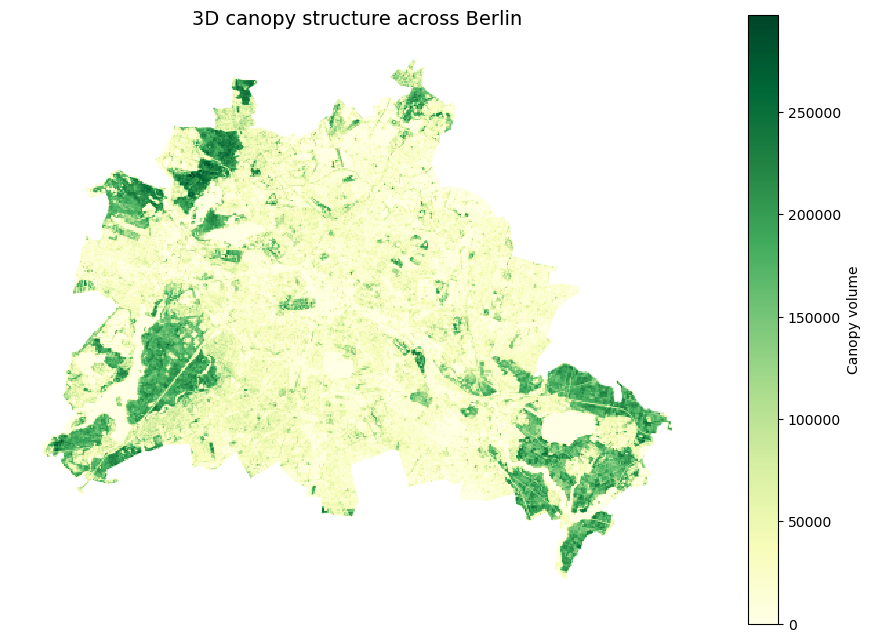

In [11]:
fig, ax = plt.subplots(figsize=(9, 9))

berlin.plot(
    column="chm_volume",
    cmap="YlGn",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={
        "label": "Canopy volume",
        "shrink": 0.7
    }
)

ax.set_title(
    "3D canopy structure across Berlin",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output3_png = download_dir / "3Dcanopy_structure_across_Berlin.png"
#output1_pdf = download_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

fig.savefig(output3_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/3Dcanopy_structure_across_Berlin.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

>The colour scale now reinforces the subject of the map, while removing axes keeps attention on the spatial pattern.

But canopy **volume** is only one part of the story.

# 🌿 Map canopy area

Remember:

>- `chm_area` describes **canopy-covered area**
>- `chm_volume` describes **3D canopy structure**

Let's map canopy area using the same approach.

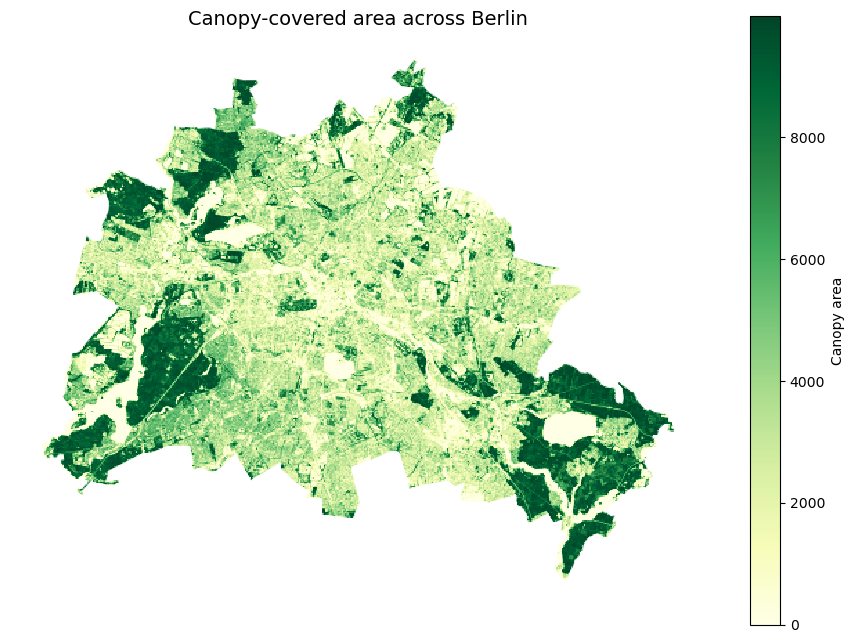

In [12]:
fig, ax = plt.subplots(figsize=(9, 9))

berlin.plot(
    column="chm_area",
    cmap="YlGn",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={
        "label": "Canopy area",
        "shrink": 0.7
    }
)

ax.set_title(
    "Canopy-covered area across Berlin",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [23]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output4_png = download_dir / "canopy_coverd_area_across_Berlin.png"
#output1_pdf = download_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

fig.savefig(output4_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/canopy_coverd_area_across_Berlin.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

```{admonition} 🕵️ Investigator challenge
:class: note

Compare the **canopy area** map with the **canopy volume** map.

Look for places where the maps appear similar — and places where they differ.

🌳 **What might a high canopy area but comparatively lower canopy volume tell us about the vegetation structure?**

# 🧠 Read the spatial evidence

Maps reveal something that summary statistics cannot: **spatial context**.

>Areas with similar canopy coverage do not necessarily have the same 3D structure. Differences between the two maps can therefore reveal variation in the **vertical structure of urban vegetation**.

This is why spatially explicit indicators are valuable when investigating urban forest structure.

```{tip}
When interpreting a thematic map, ask three questions:

**Where are the high values? → Where are the low values? → What spatial pattern do they form?**

Finding a pattern is the beginning of the investigation — not necessarily an explanation for why it exists.

# 🌳 Add the third dimension

Canopy area tells us **how much of a grid cell contains vegetation**.

But two places with similar canopy cover can still look very different: one might contain low vegetation, while another contains tall trees.

To explore this vertical dimension, we can compare canopy volume with canopy area.

In [16]:
berlin["mean_canopy_height"] = (
    berlin["chm_volume"] / berlin["chm_area"]
)

# Cells without canopy cannot have a meaningful canopy height
berlin.loc[
    berlin["chm_area"] == 0,
    "mean_canopy_height"
] = None

The new indicator gives us an approximate **mean canopy height** for each 100 m grid cell that contains vegetation.

Now our spatial question becomes much clearer:

> **Where does Berlin have relatively low or tall canopy structure?**

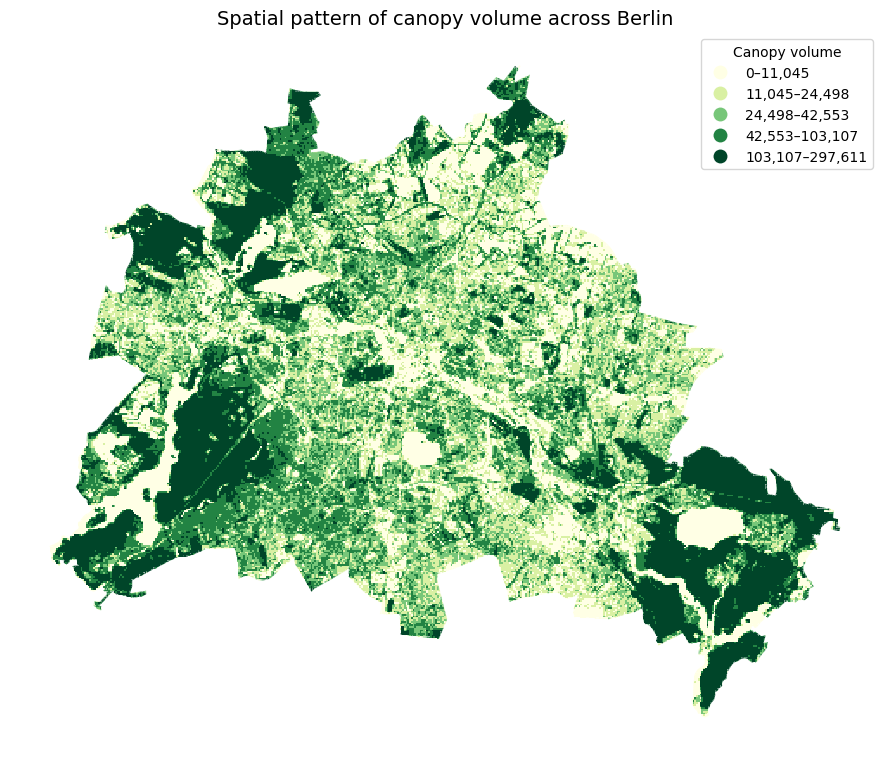

In [34]:
import matplotlib.pyplot as plt
import mapclassify

indicator = "chm_volume"

# Create five quantile classes
classifier = mapclassify.Quantiles(
    berlin[indicator].dropna(),
    k=5
)

# Create rounded legend labels
lower = berlin[indicator].min()
labels = []

for upper in classifier.bins:
    labels.append(
        f"{lower:,.0f}–{upper:,.0f}"
    )
    lower = upper

# Plot
fig, ax = plt.subplots(figsize=(9, 9))

berlin.plot(
    column=indicator,
    scheme="Quantiles",
    k=5,
    cmap="YlGn",
    linewidth=0,
    legend=True,
    legend_kwds={
        "title": "Canopy volume",
        "labels": labels
    },
    ax=ax
)

ax.set_title(
    "Spatial pattern of canopy volume across Berlin",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [33]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output5_png = download_dir / "spatial_pattern_canopy_height_Berlin.png"
#output1_pdf = download_dir / "local_climate_regulation_ugi_major_german_cities.pdf"

fig.savefig(output5_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/spatial_pattern_canopy_height_Berlin.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

# How do I read this map?

Each **100 m grid cell** is coloured according to its canopy volume.

The numbers in the legend are **ranges**. For example, `42,553–103,107` means that the canopy volume of that grid cell falls somewhere between those two values.

>- lighter green = lower canopy volume
>- darker green = higher canopy volume

The values are grouped into five classes to make the spatial pattern easier to see.

```{admonition} Mission clue solved 🔎
:class: tip

We started with columns and numbers.

Now those same values have become **spatial evidence**.

You can see that urban forest structure is not distributed uniformly — and that canopy area and 3D canopy volume provide different perspectives on the city.

```{raw} html
<div class="admonition tip">
  <p class="admonition-title">🎉 Mission Complete — Badge Unlocked!</p>

  <h3>🏆 Spatial Explorer</h3>

  <p>You successfully transformed urban forest indicators into spatial evidence.</p>

  <ul>
    <li>✔ Spatial geometries explored</li>
    <li>✔ Canopy volume mapped</li>
    <li>✔ Canopy area and volume compared</li>
    <li>✔ Local Climate Zones explored</li>
  </ul>

  <p><strong>Status:</strong> Mission 6 complete</p>

  <button onclick="completeMission6()" style="padding: 10px 16px; font-weight: bold; border-radius: 6px; cursor: pointer;">
    ✅ Complete Mission 6
  </button>

  <p id="mission-6-complete-message" style="font-weight: bold; margin-top: 12px;"></p>
</div>

<script>
function completeMission6() {

  localStorage.setItem(
    "urban_data_mission_6_completed",
    "true"
  );

  localStorage.setItem(
    "urban_data_badge_6",
    "Spatial Explorer"
  );

  localStorage.setItem(
    "urban_data_mission_6_completed_at",
    new Date().toISOString()
  );

  document.getElementById("mission-6-complete-message").innerHTML =
    "🔓 Mission 7 unlocked! Badge added to your gallery.";
}
</script>

# 🎮 Mission Progress

🟢 Mission 1: Locate & Retrieve Data ✅  
🟢 Mission 2: Inspect the Package ✅  
🟢 Mission 3: Understand the Data ✅  
🟢 Mission 4: Generate Insights ✅  
🟢 Mission 5: Create Visual Evidence ✅  
🟢 **Mission 6: Map the City ← Current**  
⚪ Mission 7: Extend the Analysis 🔒  
⚪ Final Mission: Tell the Data Story 🔒  

**Progress:** ▰▰▰▰▰▰▱▱ **6/8 Complete**

```{admonition} 🚧 Next Mission Preview
:class: note, dropdown

# 🚀 Mission 7: Extend the Analysis

You have mapped the evidence across Berlin.

Now it is time to ask **new questions of the data**.

You will learn how to:

- 🌳 investigate canopy patterns further
- 🏙️ connect indicators with urban structure
- 🔎 compare meaningful groups
- 🧠 move beyond the original analysis

**Your next challenge: follow the evidence further.**